## 1: Imports and Setup

In [1]:
import tensorflow as tf
import numpy as np
import cv2
import os
import time
from PIL import Image
import matplotlib.pyplot as plt
from tensorflow.keras.applications import VGG19
from tensorflow.keras.models import Model
from scipy.optimize import fmin_l_bfgs_b

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

# Create output directories
os.makedirs('video_frames_input', exist_ok=True)
os.makedirs('video_frames_output', exist_ok=True)
os.makedirs('video_frames_output_no_temporal', exist_ok=True)
os.makedirs('video_results', exist_ok=True)

TensorFlow version: 2.10.1
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2: Video Extraction 

In [3]:
def extract_frames(video_path, output_dir, target_size=(512, 512), max_frames=None):
    """
    Extract frames from video and resize to target size.
    
    Args:
        video_path: Path to input video
        output_dir: Directory to save frames
        target_size: (width, height) for output frames
        max_frames: Maximum frames to extract (None = all)
    
    Returns:
        frame_count, fps
    """
    cap = cv2.VideoCapture(video_path)
    
    if not cap.isOpened():
        raise ValueError(f"Cannot open video: {video_path}")
    
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    print(f"Video info:")
    print(f"  - Original size: {width}x{height}")
    print(f"  - FPS: {fps}")
    print(f"  - Total frames: {total_frames}")
    print(f"  - Duration: {total_frames/fps:.2f} seconds")
    print(f"  - Target size: {target_size[0]}x{target_size[1]}")
    
    if max_frames:
        total_frames = min(total_frames, max_frames)
        print(f"  - Limiting to: {max_frames} frames")
    
    frame_count = 0
    
    while frame_count < total_frames:
        ret, frame = cap.read()
        if not ret:
            break
        
        # Resize frame
        frame_resized = cv2.resize(frame, target_size)
        
        # Save frame
        frame_path = os.path.join(output_dir, f"frame_{frame_count:04d}.png")
        cv2.imwrite(frame_path, frame_resized)
        
        frame_count += 1
        
        if frame_count % 30 == 0:
            print(f"  Extracted {frame_count}/{total_frames} frames...")
    
    cap.release()
    
    print(f"\n✓ Extracted {frame_count} frames to {output_dir}/")
    print(f"✓ Estimated processing time: {frame_count * 60 / 60:.1f} minutes ({frame_count * 60 / 3600:.1f} hours)")
    
    return frame_count, fps


# ============== CONFIGURE AND RUN ==============
VIDEO_PATH = "NST_video_test.mp4"  
TARGET_SIZE = (512, 512)       # Use 256x256 for faster testing
MAX_FRAMES = None              # Set to 30 for quick test (1 second)

# Extract frames
frame_count, fps = extract_frames(
    VIDEO_PATH,
    'video_frames_input',
    target_size=TARGET_SIZE,
    max_frames=MAX_FRAMES
)

Video info:
  - Original size: 2560x1440
  - FPS: 25.0
  - Total frames: 192
  - Duration: 7.68 seconds
  - Target size: 512x512
  Extracted 30/192 frames...
  Extracted 60/192 frames...
  Extracted 90/192 frames...
  Extracted 120/192 frames...
  Extracted 150/192 frames...
  Extracted 180/192 frames...

✓ Extracted 192 frames to video_frames_input/
✓ Estimated processing time: 192.0 minutes (3.2 hours)


## 3: Load Style Image

Style image loaded: (1, 512, 512, 3)


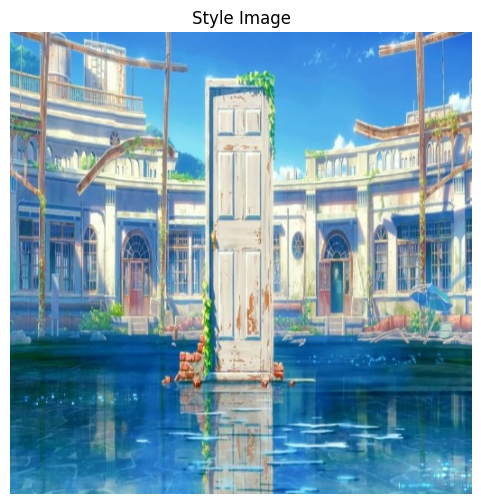

In [4]:
def load_and_preprocess_image(image_path, target_size=(512, 512)):
    """Load image and preprocess for VGG19."""
    img = Image.open(image_path).convert('RGB')
    img = img.resize(target_size)
    img_array = np.array(img, dtype=np.float32)
    img_array = np.expand_dims(img_array, axis=0)
    # VGG19 preprocessing
    img_array = tf.keras.applications.vgg19.preprocess_input(img_array)
    return img_array


def load_frame(frame_path, target_size=(512, 512)):
    """Load a single frame."""
    img = cv2.imread(frame_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, target_size)
    img_array = np.array(img, dtype=np.float32)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = tf.keras.applications.vgg19.preprocess_input(img_array)
    return img_array


# Load style image
STYLE_IMAGE_PATH = "Animate_512x512.jpg"  # <-- Your anime style image
style_image = load_and_preprocess_image(STYLE_IMAGE_PATH, TARGET_SIZE)
print(f"Style image loaded: {style_image.shape}")

# Display style image
plt.figure(figsize=(6, 6))
plt.imshow(Image.open(STYLE_IMAGE_PATH))
plt.title("Style Image")
plt.axis('off')
plt.show()


## 4: VGG19 Model Setup

In [5]:
# Content and style layers
CONTENT_LAYERS = ['block4_conv2']
STYLE_LAYERS = ['block1_conv1', 'block2_conv1', 'block3_conv1', 'block4_conv1', 'block5_conv1']

def get_model():
    """Create VGG19 model for feature extraction."""
    vgg = VGG19(include_top=False, weights='imagenet')
    vgg.trainable = False
    
    content_outputs = [vgg.get_layer(name).output for name in CONTENT_LAYERS]
    style_outputs = [vgg.get_layer(name).output for name in STYLE_LAYERS]
    
    model_outputs = content_outputs + style_outputs
    
    return Model(inputs=vgg.input, outputs=model_outputs)

# Build model
vgg_model = get_model()
print(f"VGG19 model loaded with {len(CONTENT_LAYERS)} content + {len(STYLE_LAYERS)} style layers")

VGG19 model loaded with 1 content + 5 style layers


## 5: Loss Functions (from your existing NST_FYP.ipynb)

In [6]:
def gram_matrix(tensor):
    """Compute Gram matrix for style representation."""
    batch, h, w, c = tensor.shape
    features = tf.reshape(tensor, [batch, h * w, c])
    gram = tf.matmul(features, features, transpose_a=True)
    return gram / tf.cast(h * w * c, tf.float32)


def content_loss(content_features, generated_features):
    """MSE between content and generated features."""
    return tf.reduce_mean(tf.square(content_features - generated_features))


def style_loss(style_features, generated_features):
    """MSE between Gram matrices."""
    style_gram = gram_matrix(style_features)
    generated_gram = gram_matrix(generated_features)
    return tf.reduce_mean(tf.square(style_gram - generated_gram))


def compute_edge_map(image):
    """Compute Sobel edge map."""
    sobel_x = tf.constant([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=tf.float32)
    sobel_y = tf.constant([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=tf.float32)
    sobel_x = tf.reshape(sobel_x, [3, 3, 1, 1])
    sobel_y = tf.reshape(sobel_y, [3, 3, 1, 1])
    
    gray = tf.reduce_mean(image, axis=-1, keepdims=True)
    edges_x = tf.nn.conv2d(gray, sobel_x, strides=[1,1,1,1], padding='SAME')
    edges_y = tf.nn.conv2d(gray, sobel_y, strides=[1,1,1,1], padding='SAME')
    
    return tf.sqrt(tf.square(edges_x) + tf.square(edges_y) + 1e-6)


def edge_loss(content_image, generated_image):
    """Edge preservation loss."""
    content_edges = compute_edge_map(content_image)
    generated_edges = compute_edge_map(generated_image)
    return tf.reduce_mean(tf.square(content_edges - generated_edges))


def box_filter(image, radius):
    """Box filter for guided filter."""
    kernel_size = 2 * radius + 1
    kernel = tf.ones([kernel_size, kernel_size, 1, 1], dtype=tf.float32)
    kernel = kernel / (kernel_size * kernel_size)
    
    channels = tf.split(image, num_or_size_splits=3, axis=-1)
    filtered = [tf.nn.conv2d(ch, kernel, strides=[1,1,1,1], padding='SAME') for ch in channels]
    return tf.concat(filtered, axis=-1)


def guided_filter(guidance, source, radius=4, epsilon=0.01):
    """Guided filter for surface smoothing."""
    mean_g = box_filter(guidance, radius)
    mean_s = box_filter(source, radius)
    cov_gs = box_filter(guidance * source, radius) - mean_g * mean_s
    var_g = box_filter(guidance * guidance, radius) - mean_g * mean_g
    a = cov_gs / (var_g + epsilon)
    b = mean_s - a * mean_g
    return box_filter(a, radius) * guidance + box_filter(b, radius)


def surface_loss(content_image, generated_image):
    """Surface smoothing loss."""
    smoothed = guided_filter(content_image, generated_image)
    return tf.reduce_mean(tf.square(generated_image - smoothed))


def temporal_loss(current_image, previous_image):
    """
    Temporal consistency loss - penalizes differences from previous frame.
    This is the KEY ADDITION for video processing.
    """
    return tf.reduce_mean(tf.square(current_image - previous_image))


## 6: Weights Configuration

In [7]:
# Use V3/V4 configuration (user-preferred)
WEIGHTS = {
    'content_weight': 2.5e-8,
    'style_weight': 1e-4,
    'tv_weight': 1e-6,
    'edge_weight': 0,          # Disabled for anime aesthetic
    'surface_weight': 10000,
    'temporal_weight': 5000,   # NEW: Temporal consistency weight
}

print("Weight configuration:")
for k, v in WEIGHTS.items():
    print(f"  {k}: {v}")

Weight configuration:
  content_weight: 2.5e-08
  style_weight: 0.0001
  tv_weight: 1e-06
  edge_weight: 0
  surface_weight: 10000
  temporal_weight: 5000


## 7: Optimization Setup

In [8]:
class VideoFrameEvaluator:
    """
    Evaluator for single frame optimization with temporal loss.
    """
    def __init__(self, content_image, style_image, prev_stylized, img_shape, weights):
        self.content_image = tf.constant(content_image, dtype=tf.float32)
        self.style_image = tf.constant(style_image, dtype=tf.float32)
        self.prev_stylized = tf.constant(prev_stylized, dtype=tf.float32) if prev_stylized is not None else None
        self.img_shape = img_shape
        self.weights = weights
        self.loss_value = None
        self.grads_value = None
        
        # Pre-compute style features (constant for all frames)
        style_outputs = vgg_model(self.style_image)
        self.style_features = style_outputs[len(CONTENT_LAYERS):]
        
        # Pre-compute content features
        content_outputs = vgg_model(self.content_image)
        self.content_features = content_outputs[:len(CONTENT_LAYERS)]
    
    def compute_loss(self, generated_image):
        """Compute total loss including temporal loss."""
        # Get generated features
        gen_outputs = vgg_model(generated_image)
        gen_content_features = gen_outputs[:len(CONTENT_LAYERS)]
        gen_style_features = gen_outputs[len(CONTENT_LAYERS):]
        
        total_loss = tf.zeros(shape=())
        
        # Content loss
        for cf, gf in zip(self.content_features, gen_content_features):
            total_loss += self.weights['content_weight'] * content_loss(cf, gf)
        
        # Style loss
        for sf, gf in zip(self.style_features, gen_style_features):
            total_loss += self.weights['style_weight'] * style_loss(sf, gf)
        
        # TV loss
        total_loss += self.weights['tv_weight'] * tf.image.total_variation(generated_image)
        
        # Edge loss
        if self.weights['edge_weight'] > 0:
            total_loss += self.weights['edge_weight'] * edge_loss(self.content_image, generated_image)
        
        # Surface loss
        if self.weights['surface_weight'] > 0:
            total_loss += self.weights['surface_weight'] * surface_loss(self.content_image, generated_image)
        
        # Temporal loss (KEY FOR VIDEO)
        if self.prev_stylized is not None and self.weights['temporal_weight'] > 0:
            total_loss += self.weights['temporal_weight'] * temporal_loss(generated_image, self.prev_stylized)
        
        return total_loss
    
    def loss(self, x):
        """Loss function for L-BFGS."""
        x = x.reshape(self.img_shape)
        x = tf.constant(x, dtype=tf.float32)
        
        with tf.GradientTape() as tape:
            tape.watch(x)
            loss = self.compute_loss(x)
        
        grads = tape.gradient(loss, x)
        
        self.loss_value = float(loss)
        self.grads_value = grads.numpy().flatten().astype('float64')
        
        return self.loss_value
    
    def grads(self, x):
        """Return cached gradients."""
        return self.grads_value


def stylize_frame(content_image, style_image, prev_stylized, weights, 
                  init_image=None, iterations=15):
    """
    Stylize a single frame.
    
    Args:
        content_image: Current frame (preprocessed)
        style_image: Style reference (preprocessed)
        prev_stylized: Previous stylized frame (for temporal loss)
        weights: Loss weights dictionary
        init_image: Initialization (use prev_stylized for temporal coherence)
        iterations: L-BFGS iterations
    
    Returns:
        Stylized frame
    """
    img_shape = content_image.shape
    
    # Initialize from previous frame (warm start) or content
    if init_image is not None:
        x = init_image.flatten().astype('float64')
    else:
        x = content_image.flatten().astype('float64')
    
    evaluator = VideoFrameEvaluator(content_image, style_image, prev_stylized, img_shape, weights)
    
    x, min_val, info = fmin_l_bfgs_b(
        evaluator.loss,
        x,
        fprime=evaluator.grads,
        maxiter=iterations,
        disp=False
    )
    
    return x.reshape(img_shape)


print(" Optimization functions defined")

 Optimization functions defined


## 8: Main Video Processing Loop

In [9]:
def deprocess_image(img):
    """Convert VGG-preprocessed image back to displayable format."""
    img = img.copy()
    if len(img.shape) == 4:
        img = img[0]
    
    # Reverse VGG preprocessing
    img[:, :, 0] += 103.939
    img[:, :, 1] += 116.779
    img[:, :, 2] += 123.68
    img = img[:, :, ::-1]  # BGR to RGB
    
    img = np.clip(img, 0, 255).astype('uint8')
    return img


def process_video(input_dir, output_dir, style_image, weights, 
                  iterations=15, use_temporal=True):
    """
    Process all frames with temporal consistency.
    
    Args:
        input_dir: Directory containing input frames
        output_dir: Directory for output frames
        style_image: Preprocessed style image
        weights: Loss weights
        iterations: L-BFGS iterations per frame
        use_temporal: Whether to use temporal loss
    
    Returns:
        List of processing times per frame
    """
    # Get sorted frame list
    frame_files = sorted([f for f in os.listdir(input_dir) if f.endswith('.png')])
    total_frames = len(frame_files)
    
    print(f"\n{'='*60}")
    print(f"Processing {total_frames} frames")
    print(f"Temporal loss: {'ENABLED' if use_temporal else 'DISABLED'}")
    print(f"Iterations per frame: {iterations}")
    print(f"{'='*60}\n")
    
    prev_stylized = None
    times = []
    
    for i, frame_file in enumerate(frame_files):
        start_time = time.time()
        
        # Load current frame
        frame_path = os.path.join(input_dir, frame_file)
        content_image = load_frame(frame_path, TARGET_SIZE)
        
        # Determine initialization
        if prev_stylized is not None and use_temporal:
            init_image = prev_stylized  # Warm start from previous
        else:
            init_image = content_image  # Cold start
        
        # Set temporal weight
        current_weights = weights.copy()
        if not use_temporal:
            current_weights['temporal_weight'] = 0
        
        # Stylize frame
        stylized = stylize_frame(
            content_image, 
            style_image, 
            prev_stylized if use_temporal else None,
            current_weights,
            init_image=init_image,
            iterations=iterations
        )
        
        # Save output
        output_image = deprocess_image(stylized)
        output_path = os.path.join(output_dir, frame_file)
        cv2.imwrite(output_path, cv2.cvtColor(output_image, cv2.COLOR_RGB2BGR))
        
        # Update previous frame
        prev_stylized = stylized
        
        elapsed = time.time() - start_time
        times.append(elapsed)
        
        # Progress update
        eta = np.mean(times) * (total_frames - i - 1)
        print(f"Frame {i+1:3d}/{total_frames} | Time: {elapsed:5.1f}s | ETA: {eta/60:5.1f} min")
    
    print(f"\n{'='*60}")
    print(f"✓ Processing complete!")
    print(f"Total time: {sum(times)/60:.1f} minutes")
    print(f"Average time per frame: {np.mean(times):.1f} seconds")
    print(f"{'='*60}")
    
    return times

## 9: Run Processing WITH Temporal Loss

In [10]:

times_with_temporal = process_video(
    'video_frames_input',
    'video_frames_output',
    style_image,
    WEIGHTS,
    iterations=15,
    use_temporal=True
)



Processing 192 frames
Temporal loss: ENABLED
Iterations per frame: 15

Frame   1/192 | Time:  16.4s | ETA:  52.2 min
Frame   2/192 | Time:   5.0s | ETA:  33.8 min
Frame   3/192 | Time:   5.6s | ETA:  28.3 min
Frame   4/192 | Time:   6.3s | ETA:  26.0 min
Frame   5/192 | Time:   4.9s | ETA:  23.7 min
Frame   6/192 | Time:   5.7s | ETA:  22.6 min
Frame   7/192 | Time:   6.6s | ETA:  22.2 min
Frame   8/192 | Time:   4.7s | ETA:  21.1 min
Frame   9/192 | Time:  13.3s | ETA:  23.2 min
Frame  10/192 | Time:   9.4s | ETA:  23.6 min
Frame  11/192 | Time:   4.9s | ETA:  22.7 min
Frame  12/192 | Time:   9.3s | ETA:  23.0 min
Frame  13/192 | Time:   9.1s | ETA:  23.2 min
Frame  14/192 | Time:   4.5s | ETA:  22.4 min
Frame  15/192 | Time:   9.2s | ETA:  22.6 min
Frame  16/192 | Time:   6.9s | ETA:  22.3 min
Frame  17/192 | Time:   7.8s | ETA:  22.2 min
Frame  18/192 | Time:   4.2s | ETA:  21.6 min
Frame  19/192 | Time:   4.9s | ETA:  21.0 min
Frame  20/192 | Time:   8.4s | ETA:  21.1 min
Frame  2

In [11]:
print("\nProcessing WITHOUT temporal consistency (for comparison)...")
times_no_temporal = process_video(
    'video_frames_input',
    'video_frames_output_no_temporal',
    style_image,
    WEIGHTS,
    iterations=15,
    use_temporal=False
)


Processing WITHOUT temporal consistency (for comparison)...

Processing 192 frames
Temporal loss: DISABLED
Iterations per frame: 15

Frame   1/192 | Time:   5.3s | ETA:  16.7 min
Frame   2/192 | Time:   4.6s | ETA:  15.6 min
Frame   3/192 | Time:   4.6s | ETA:  15.2 min
Frame   4/192 | Time:   4.7s | ETA:  15.0 min
Frame   5/192 | Time:   4.7s | ETA:  14.8 min
Frame   6/192 | Time:   4.7s | ETA:  14.7 min
Frame   7/192 | Time:   4.6s | ETA:  14.6 min
Frame   8/192 | Time:   4.6s | ETA:  14.4 min
Frame   9/192 | Time:   4.6s | ETA:  14.3 min
Frame  10/192 | Time:   4.6s | ETA:  14.2 min
Frame  11/192 | Time:   4.6s | ETA:  14.1 min
Frame  12/192 | Time:   4.7s | ETA:  14.1 min
Frame  13/192 | Time:   4.7s | ETA:  14.0 min
Frame  14/192 | Time:   4.7s | ETA:  13.9 min
Frame  15/192 | Time:   4.6s | ETA:  13.8 min
Frame  16/192 | Time:   4.6s | ETA:  13.7 min
Frame  17/192 | Time:   4.6s | ETA:  13.6 min
Frame  18/192 | Time:   4.6s | ETA:  13.5 min
Frame  19/192 | Time:   4.6s | ETA:  1

## 11: Create Output Videos

In [16]:
import cv2
import os

def frames_to_video_h264(frames_dir, output_path, fps=30):
    """Create video with H.264 codec (better compatibility)."""
    frame_files = sorted([f for f in os.listdir(frames_dir) if f.endswith('.png')])
    
    if not frame_files:
        print(f"No frames found in {frames_dir}")
        return
    
    # Read first frame to get dimensions
    first_frame = cv2.imread(os.path.join(frames_dir, frame_files[0]))
    h, w = first_frame.shape[:2]
    
    fourcc = cv2.VideoWriter_fourcc(*'avc1')
    
    writer = cv2.VideoWriter(output_path, fourcc, fps, (w, h))
    
    if not writer.isOpened():
        print("H264 failed, trying XVID...")
        fourcc = cv2.VideoWriter_fourcc(*'XVID')
        output_path = output_path.replace('.mp4', '.avi')
        writer = cv2.VideoWriter(output_path, fourcc, fps, (w, h))
    
    for frame_file in frame_files:
        frame = cv2.imread(os.path.join(frames_dir, frame_file))
        writer.write(frame)
    
    writer.release()
    print(f"✓ Video saved: {output_path}")

# Recreate all videos
frames_to_video_h264('video_frames_output', 'video_results/ours_with_temporal.mp4', fps=30)
frames_to_video_h264('video_frames_output_no_temporal', 'video_results/ours_no_temporal.mp4', fps=30)
frames_to_video_h264('video_frames_animegan', 'video_results/animegan.mp4', fps=30)
frames_to_video_h264('video_frames_input', 'video_results/original.mp4', fps=30)

✓ Video saved: video_results/ours_with_temporal.mp4
✓ Video saved: video_results/ours_no_temporal.mp4
✓ Video saved: video_results/animegan.mp4
✓ Video saved: video_results/original.mp4


## 12: Evaluation Metrics

In [13]:
def compute_temporal_consistency(frames_dir):
    """
    Compute temporal consistency metrics.
    Lower variance = more consistent (less flickering)
    """
    frame_files = sorted([f for f in os.listdir(frames_dir) if f.endswith('.png')])
    
    frame_diffs = []
    prev_frame = None
    
    for frame_file in frame_files:
        frame = cv2.imread(os.path.join(frames_dir, frame_file))
        frame = frame.astype(np.float32) / 255.0
        
        if prev_frame is not None:
            diff = np.mean(np.abs(frame - prev_frame))
            frame_diffs.append(diff)
        
        prev_frame = frame
    
    return {
        'mean_diff': np.mean(frame_diffs),
        'std_diff': np.std(frame_diffs),
        'max_diff': np.max(frame_diffs),
        'min_diff': np.min(frame_diffs)
    }


def compute_flatness(frames_dir, sample_frames=10):
    """Compute average flatness score across sampled frames."""
    frame_files = sorted([f for f in os.listdir(frames_dir) if f.endswith('.png')])
    
    # Sample frames evenly
    indices = np.linspace(0, len(frame_files)-1, sample_frames, dtype=int)
    
    flatness_scores = []
    for idx in indices:
        frame = cv2.imread(os.path.join(frames_dir, frame_files[idx]))
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        laplacian = cv2.Laplacian(gray, cv2.CV_64F)
        variance = laplacian.var()
        flatness = 1.0 / (1.0 + variance / 500.0)
        flatness_scores.append(flatness)
    
    return np.mean(flatness_scores)


# Compute metrics
print("\n" + "="*60)
print("EVALUATION METRICS")
print("="*60)

metrics_with = compute_temporal_consistency('video_frames_output')
metrics_without = compute_temporal_consistency('video_frames_output_no_temporal')

flatness_with = compute_flatness('video_frames_output')
flatness_without = compute_flatness('video_frames_output_no_temporal')

print(f"\n{'Metric':<25} {'With Temporal':<15} {'Without Temporal':<15} {'Improvement':<15}")
print("-"*70)
print(f"{'Mean Frame Diff':<25} {metrics_with['mean_diff']:<15.4f} {metrics_without['mean_diff']:<15.4f} {(metrics_without['mean_diff']-metrics_with['mean_diff'])/metrics_without['mean_diff']*100:>+.1f}%")
print(f"{'Std Frame Diff':<25} {metrics_with['std_diff']:<15.4f} {metrics_without['std_diff']:<15.4f} {(metrics_without['std_diff']-metrics_with['std_diff'])/metrics_without['std_diff']*100:>+.1f}%")
print(f"{'Max Frame Diff':<25} {metrics_with['max_diff']:<15.4f} {metrics_without['max_diff']:<15.4f}")
print(f"{'Flatness Score':<25} {flatness_with:<15.4f} {flatness_without:<15.4f}")



EVALUATION METRICS

Metric                    With Temporal   Without Temporal Improvement    
----------------------------------------------------------------------
Mean Frame Diff           0.0015          0.0267          +94.5%
Std Frame Diff            0.0018          0.0037          +52.2%
Max Frame Diff            0.0162          0.0312         
Flatness Score            0.8426          0.1328         


## 13: Visual Comparison

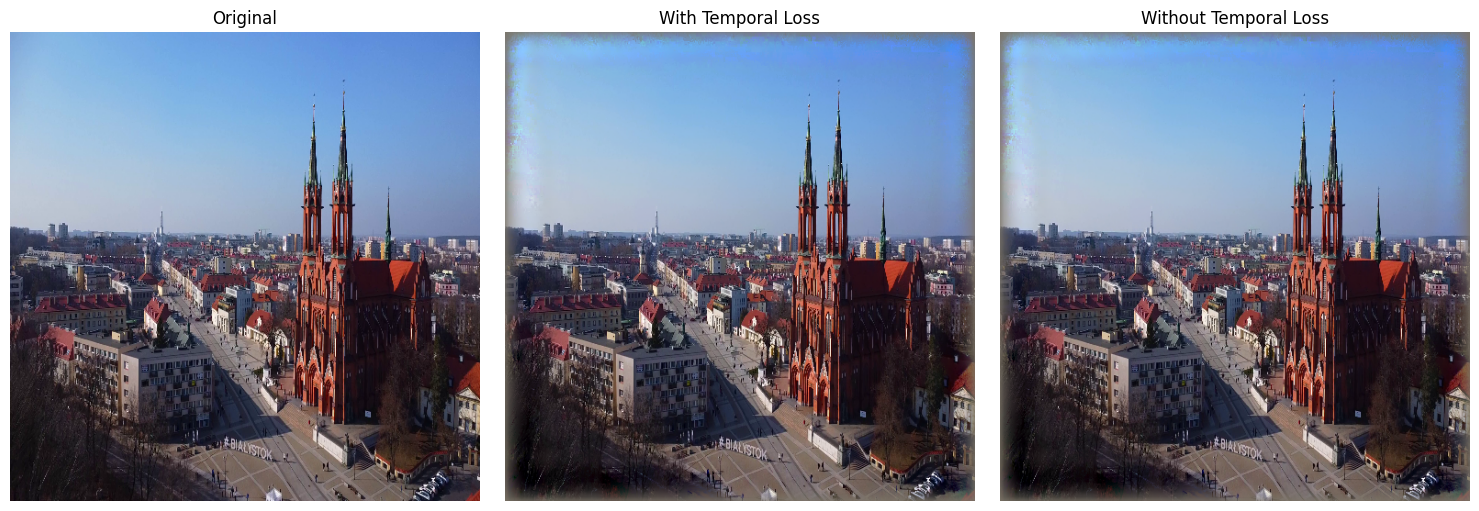

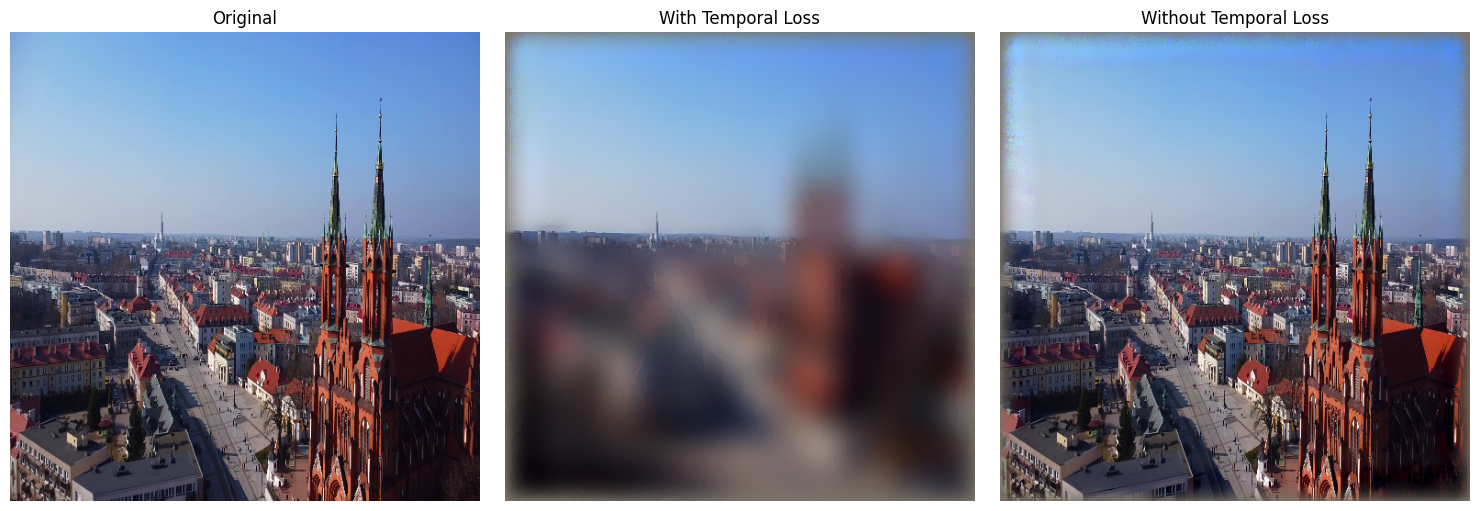

In [14]:
def show_frame_comparison(frame_idx=0):
    """Show side-by-side comparison of a specific frame."""
    frame_file = f"frame_{frame_idx:04d}.png"
    
    original = cv2.imread(f'video_frames_input/{frame_file}')
    original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
    
    with_temporal = cv2.imread(f'video_frames_output/{frame_file}')
    with_temporal = cv2.cvtColor(with_temporal, cv2.COLOR_BGR2RGB)
    
    without_temporal = cv2.imread(f'video_frames_output_no_temporal/{frame_file}')
    without_temporal = cv2.cvtColor(without_temporal, cv2.COLOR_BGR2RGB)
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(original)
    axes[0].set_title('Original')
    axes[0].axis('off')
    
    axes[1].imshow(with_temporal)
    axes[1].set_title('With Temporal Loss')
    axes[1].axis('off')
    
    axes[2].imshow(without_temporal)
    axes[2].set_title('Without Temporal Loss')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.savefig('video_results/frame_comparison.png', dpi=150)
    plt.show()


# Show comparison for first frame
show_frame_comparison(0)

# Show comparison for middle frame
total = len([f for f in os.listdir('video_frames_input') if f.endswith('.png')])
show_frame_comparison(total // 2)

In [15]:
print(f"""
Input Video:
  - Frames: {total}
  - Duration: {total/fps:.1f} seconds
  - Resolution: {TARGET_SIZE[0]}x{TARGET_SIZE[1]}

Processing:
  - Iterations per frame: 15
  - Avg time per frame: {np.mean(times_with_temporal):.1f}s
  - Total time (with temporal): {sum(times_with_temporal)/60:.1f} minutes
  - Total time (without temporal): {sum(times_no_temporal)/60:.1f} minutes

Temporal Consistency Results:
  - Mean frame diff (with temporal): {metrics_with['mean_diff']:.4f}
  - Mean frame diff (without temporal): {metrics_without['mean_diff']:.4f}
  - Improvement: {(metrics_without['mean_diff']-metrics_with['mean_diff'])/metrics_without['mean_diff']*100:.1f}%

""")



Input Video:
  - Frames: 192
  - Duration: 7.7 seconds
  - Resolution: 512x512

Processing:
  - Iterations per frame: 15
  - Avg time per frame: 7.8s
  - Total time (with temporal): 24.9 minutes
  - Total time (without temporal): 14.8 minutes

Temporal Consistency Results:
  - Mean frame diff (with temporal): 0.0015
  - Mean frame diff (without temporal): 0.0267
  - Improvement: 94.5%


